In [1]:
import sys, json, os
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.fairness import make_groups, group_table, ORDERS

X_test = pd.read_parquet("../data/processed/X_test.parquet")
tp_df = pd.read_parquet("../data/processed/test_predictions.parquet")
t = json.load(open("../reports/final_decision.json"))["flag_threshold"]
assert (tp_df.index == X_test.index).all()

y, p = tp_df["y"].values, tp_df["p"].values
groups = make_groups(X_test)
print("threshold:", round(t, 4), "  test rows:", len(y))

threshold: 0.0925   test rows: 90493


In [2]:
audits = {k: group_table(y, p, groups[k], t, ORDERS[k]) for k in groups}
cols = ["n", "cases", "observed_rate", "mean_predicted", "roc_auc",
        "recall", "fpr", "precision", "flagged_pct", "note"]
for k, tab in audits.items():
    print(f"\n=== {k} ===")
    display(tab[cols].round(3))

os.makedirs("../reports", exist_ok=True)
pd.concat(audits, names=["attribute"]).round(5).to_csv("../reports/fairness_audit.csv")


=== sex ===


,n,cases,observed_rate,mean_predicted,roc_auc,recall,fpr,precision,flagged_pct,note
group,,,,,,,,,,
Male,43013,4914,0.114,0.114,0.828,0.857,0.353,0.239,41.036,
Female,47480,3554,0.075,0.075,0.826,0.716,0.235,0.198,27.125,



=== age ===


,n,cases,observed_rate,mean_predicted,roc_auc,recall,fpr,precision,flagged_pct,note
group,,,,,,,,,,
18-24,5834,41,0.007,0.008,0.770,0.122,0.001,0.385,0.223,few cases: interpret with caution
25-34,9981,148,0.015,0.011,0.790,0.108,0.006,0.208,0.771,
35-44,12029,236,0.020,0.022,0.795,0.250,0.026,0.159,3.076,
45-54,12866,644,0.050,0.049,0.807,0.531,0.109,0.205,12.995,
55-64,15727,1512,0.096,0.095,0.779,0.714,0.304,0.200,34.374,
65+,34056,5887,0.173,0.174,0.737,0.893,0.630,0.229,67.512,



=== income ===


,n,cases,observed_rate,mean_predicted,roc_auc,recall,fpr,precision,flagged_pct,note
group,,,,,,,,,,
<$25k,10569,1624,0.154,0.152,0.792,0.889,0.482,0.251,54.471,
$25-50k,18119,2121,0.117,0.118,0.814,0.840,0.380,0.226,43.413,
$50-100k,22331,1962,0.088,0.086,0.831,0.785,0.271,0.218,31.597,
$100k+,22380,1210,0.054,0.053,0.844,0.633,0.146,0.198,17.279,
Unknown,17094,1551,0.091,0.094,0.822,0.790,0.306,0.205,35.006,



=== race_ethnicity ===


,n,cases,observed_rate,mean_predicted,roc_auc,recall,fpr,precision,flagged_pct,note
group,,,,,,,,,,
White,65160,6693,0.103,0.100,0.828,0.811,0.314,0.228,36.464,
Black,7006,567,0.081,0.092,0.821,0.792,0.295,0.191,33.486,
AI/AN,1198,151,0.126,0.110,0.844,0.834,0.309,0.281,37.479,
Asian,2467,74,0.030,0.048,0.849,0.595,0.138,0.118,15.160,few cases: interpret with caution
NHPI,387,37,0.096,0.084,0.812,0.703,0.249,0.230,29.199,few cases: interpret with caution
Other,758,83,0.109,0.103,0.838,0.843,0.324,0.242,38.127,few cases: interpret with caution
Multiracial,2129,176,0.083,0.083,0.841,0.750,0.243,0.217,28.511,
Hispanic,9677,529,0.055,0.061,0.816,0.671,0.180,0.177,20.709,
Unknown,1711,158,0.092,0.098,0.820,0.791,0.298,0.213,34.366,


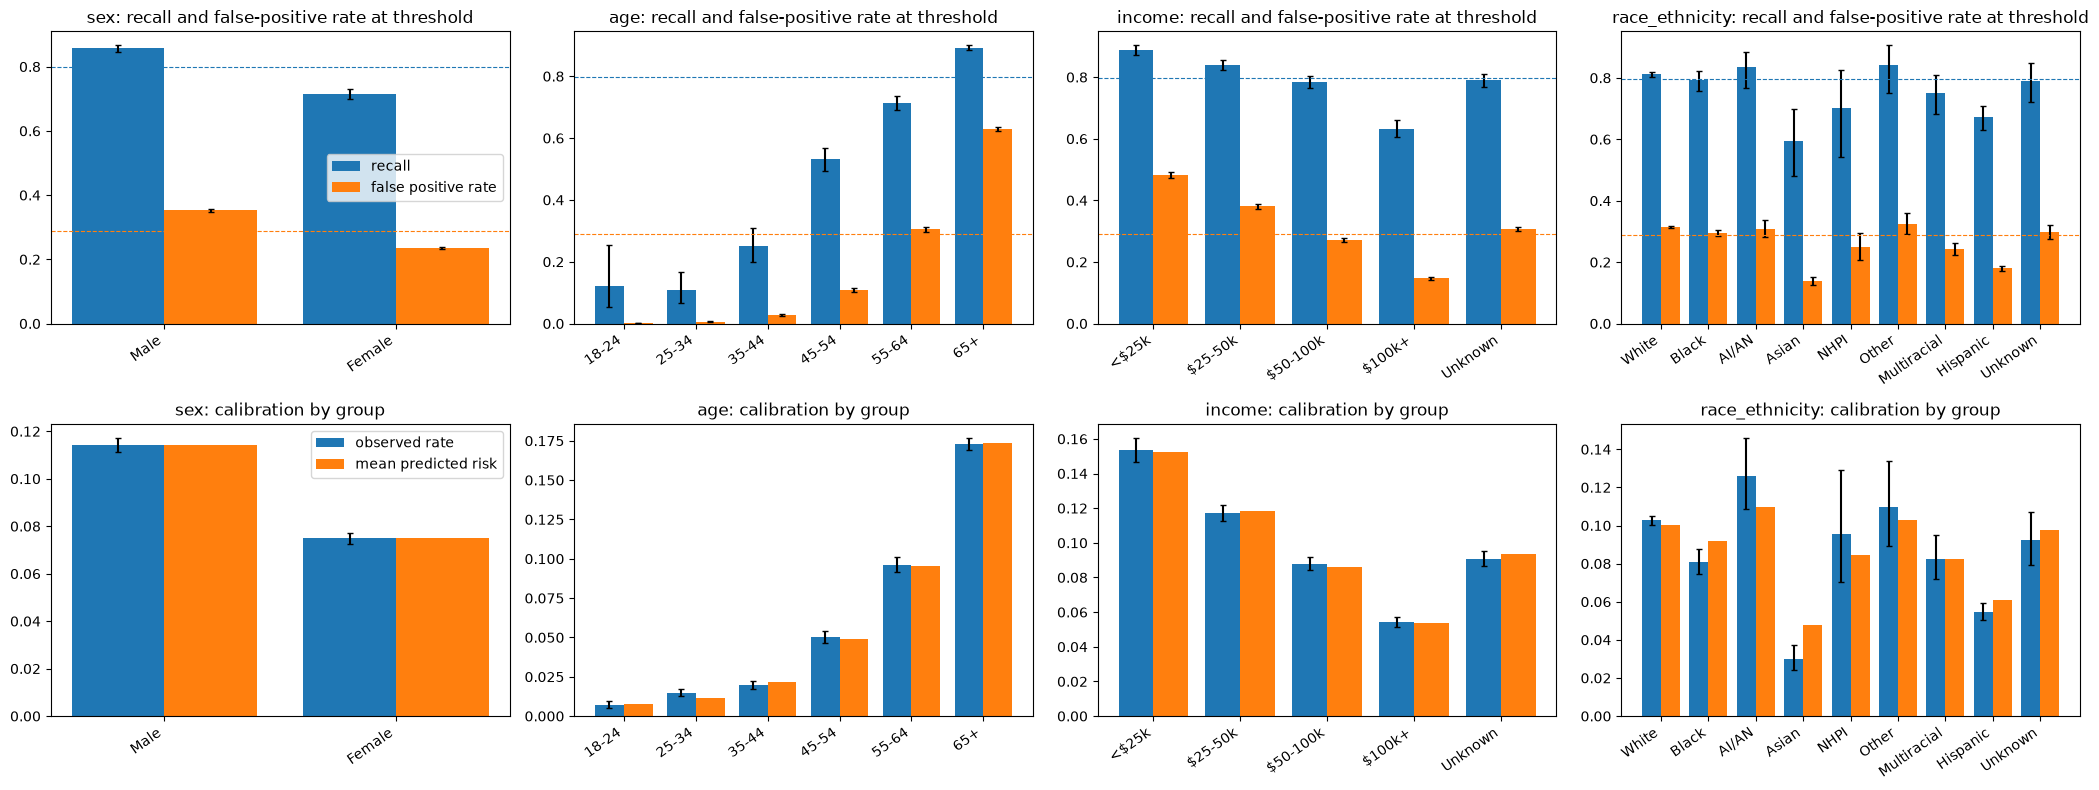

In [3]:
flag = p >= t
overall_recall = (flag & (y == 1)).sum() / (y == 1).sum()
overall_fpr = (flag & (y == 0)).sum() / (y == 0).sum()

fig, axes = plt.subplots(2, 4, figsize=(21, 8))
for j, (name, tab) in enumerate(audits.items()):
    x = np.arange(len(tab))
    top, bot = axes[0, j], axes[1, j]

    top.bar(x - 0.2, tab["recall"], 0.4, capsize=2, label="recall",
            yerr=[tab["recall"] - tab["recall_lo"], tab["recall_hi"] - tab["recall"]])
    top.bar(x + 0.2, tab["fpr"], 0.4, capsize=2, label="false positive rate",
            yerr=[tab["fpr"] - tab["fpr_lo"], tab["fpr_hi"] - tab["fpr"]])
    top.axhline(overall_recall, ls="--", color="tab:blue", lw=0.8)
    top.axhline(overall_fpr, ls="--", color="tab:orange", lw=0.8)
    top.set_title(f"{name}: recall and false-positive rate at threshold")

    bot.bar(x - 0.2, tab["observed_rate"], 0.4, capsize=2, label="observed rate",
            yerr=[tab["observed_rate"] - tab["obs_lo"], tab["obs_hi"] - tab["observed_rate"]])
    bot.bar(x + 0.2, tab["mean_predicted"], 0.4, label="mean predicted risk")
    bot.set_title(f"{name}: calibration by group")

    for a in (top, bot):
        a.set_xticks(x)
        a.set_xticklabels(tab.index, rotation=35, ha="right")

axes[0, 0].legend()
axes[1, 0].legend()
plt.tight_layout()
plt.savefig("../reports/figures/15_fairness_audit.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
d = pd.DataFrame({"age": groups["age"].values, "y": y, "flag": p >= t})
young = d[d.age.isin(["18-24", "25-34", "35-44"])]
under55 = d[d.age.isin(["18-24", "25-34", "35-44", "45-54"])]
print("recall ages 18-44:", round(young[young.y == 1].flag.mean(), 3), " cases:", int(young.y.sum()))
print("recall ages 18-54:", round(under55[under55.y == 1].flag.mean(), 3), " cases:", int(under55.y.sum()))
print("share of all cases aged 65+:", round(((d.age == "65+") & (d.y == 1)).sum() / d.y.sum(), 3))

# race/ethnicity within the 65+ group only (largest age group, many cases per race group)
cols = ["n", "cases", "observed_rate", "mean_predicted", "recall", "fpr", "flagged_pct", "note"]
mask = (X_test["_AGE_G"] == 6).values
group_table(y[mask], p[mask], groups["race_ethnicity"][mask], t, ORDERS["race_ethnicity"])[cols].round(3)

recall ages 18-44: 0.188  cases: 425
recall ages 18-54: 0.395  cases: 1069
share of all cases aged 65+: 0.695


,n,cases,observed_rate,mean_predicted,recall,fpr,flagged_pct,note
group,,,,,,,,
White,28325,4962,0.175,0.170,0.886,0.615,66.217,
Black,2142,324,0.151,0.188,0.935,0.710,74.416,
AI/AN,345,78,0.226,0.218,0.974,0.689,75.362,few cases: interpret with caution
Asian,436,36,0.083,0.157,0.833,0.598,61.697,few cases: interpret with caution
NHPI,93,22,0.237,0.193,0.818,0.676,70.968,few cases: interpret with caution
Other,293,61,0.208,0.186,0.869,0.677,71.672,few cases: interpret with caution
Multiracial,503,108,0.215,0.201,0.889,0.706,74.553,
Hispanic,1326,195,0.147,0.199,0.979,0.756,78.884,
Unknown,593,101,0.170,0.185,0.901,0.661,70.152,


## Subgroup audit findings

The final model was audited on the test set at the fixed threshold (0.093) by sex, age, income band and race/ethnicity (race is not a model input). Intervals are 95% Wilson intervals; groups with fewer than 100 cases are flagged.

**Calibration.** Mean predicted risk matched observed risk closely within sex (male 0.114 vs 0.114, female 0.075 vs 0.075), age (e.g. 65+: 0.174 vs 0.173) and income band (e.g. < $25k: 0.152 vs 0.154; $100k+: 0.053 vs 0.054). Within-group ROC-AUC was 0.74–0.85 in every group (lowest for age 65+, 0.737).

**Age.** At a single threshold, recall rose from 12% (18–24) and 11% (25–34) to 89% (65+), with the share flagged rising from 0.2% to 67.5%. Adults aged 65+ account for 69.5% of all cases, so overall recall mainly reflects older adults; recall was about 19% for ages 18–44 and about 39% for ages 18–54 (see audit cell for exact values).

**Sex and income.** Women's recall was 71.6% vs 85.7% for men (27% vs 41% flagged), consistent with lower prevalence (7.5% vs 11.4%). Respondents with income below $25k were flagged far more often than those above $100k (54% vs 17%), with higher recall (89% vs 63%) and a higher false-positive rate (48% vs 15%). With unequal base rates, a calibrated score cannot also equalise error rates across groups.

**Race/ethnicity.** Calibration for the larger groups was within about 0.01: White 0.103 observed vs 0.100 predicted, Black 0.081 vs 0.092 (about 14% over-prediction), Hispanic 0.055 vs 0.061 (about 11%), with a similar direction for Asian respondents (0.030 vs 0.048; only 74 cases). Hispanic recall (0.67) and share flagged (21%) were lower than for White respondents (0.81, 36%), which is probably related to a younger age distribution (see within-65+ check). Small groups (Asian, NHPI, Other) have wide intervals and should not be over-interpreted.

**Interpretation and limitations.** This is a descriptive audit, not a fairness guarantee. Excluding race as an input does not prevent group differences, since income, health and other answers act as imperfect proxies. The tool should present calibrated risk probabilities rather than a single binary flag, and a single cutoff has very different practical meaning across age groups.